## Tutorial 1: Solving the states transition networks

The dyngpt package contains several pre-trained states transition networks. By providing the model name and associated parameters, one can obtain the corresponding stationary distribution. We will now demonstrate the code execution process using the autoregulatory feedback loop model model as an illustrative example.

The system state is $s={{\left( {{s}_{\text{OFF}}},{{s}_{\text{ON}}},{{s}_{\text{P}}} \right)}^{\text{T}}}\in {{\left\{ 0,1 \right\}}^{2}}\times \mathbb{N}$ where ${{s}_{\text{OFF}}}$ and ${{s}_{\text{ON}}}$ indicate whether the promoter is in the inactive or active state, and ${{s}_{\text{P}}}$ is the number of protein molecules.  Five state transition vectors characterize promoter binding/unbinding events, protein production, and degradation: 
$$\Delta _{i}^{\left( 1 \right)}=-{{\delta }_{i,\text{OFF}}}+{{\delta }_{i,\text{ON}}}-{{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 2 \right)}={{\delta }_{i,\text{OFF}}}-{{\delta }_{i,\text{ON}}}+{{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 3 \right)}={{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 4 \right)}={{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 5 \right)}=-{{\delta }_{i,\text{P}}},$$
where $ i \in \left\{ \text{OFF},\text{ON},\text{P} \right\}$ and ${{\delta }_{i,j}}$ is the Kronecker delta. The corresponding occurrence propensities depend on the current promoter state and protein count: 
$${{\lambda }_{1}}\left( s \right)={{k}_{\text{on}}}{{s}_{\text{OFF}}}{{s}_{\text{P}}},{{\lambda }_{2}}\left( s \right)={{k}_{\text{off}}}{{s}_{\text{ON}}},{{\lambda }_{3}}\left( s \right)=k_{\text{syn}}^{\text{on}}{{s}_{\text{ON}}},{{\lambda }_{4}}\left( s \right)=k_{s\text{yn}}^{\text{off}}{{s}_{\text{OFF}}},{{\lambda }_{5}}\left( s \right)={{k}_{\deg }}{{s}_{\text{P}}}.$$  
In this STN, ${{\theta }_{\text{Dyn}}}=\left\{ k_{\text{on}},k_{\text{off}},k_{\text{syn}}^{\text{off}},k_{\text{syn}}^{\text{on}},k_{\text{deg}} \right\}$.

### Load package

In [1]:
import os
import torch
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
root_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/"
sys.path.append(root_path)
os.chdir(root_path)
# import dyngpt
from dyngpt.solver import solving_state_transition_network
from dyngpt.utils.util import load_promt_prob
from dyngpt.dynmodels.afl import get_afl_model_config

/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT


### Define util functions

In [2]:
def set_font_label(ax,x_label,y_label,font_size=10,font_name='Arial',labelsize=8,tick_width=0.4): # 6.5
    ax.set_xlabel(x_label, fontsize=font_size, fontname=font_name,labelpad=1)
    ax.set_ylabel(y_label, fontsize=font_size, fontname=font_name,labelpad=1)
    ax.tick_params(axis='both', which='major', labelsize=labelsize, length=1.6, pad=1,width=tick_width)
    ax.tick_params(axis='both', which='minor', labelsize=labelsize, length=1.6,pad=1,width=tick_width)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    return ax
def plot_margin_prob(df,ax,labels,loc_pos = False,xticks=[],y_ticks=[],x_lim=0,label_values = ["Simulation","DynGPT"]):
    df.columns=label_values
    df['Category']=list(range(df.shape[0]))
    barplot = sns.barplot(x='Category', y='value', hue='variable', data=pd.melt(df, id_vars='Category'),palette=["#C9CACA","#009ACE"], ax=ax)
    barplot.margins(x=0.1) 
    if len(xticks)>0:
        ax.set_xticks(xticks)

    if len(y_ticks)>0:
        ax.set_yticks(y_ticks)
    if x_lim>0:
        ax.set_xlim(-1,x_lim)
    legend = ax.legend(loc='upper right', fontsize='4.8', title_fontsize='6')

    set_font_label(ax,x_label=labels[0],y_label=labels[1])

def calculate_probabilities(data):
    """
    Calculate the probability distribution of each integer in the list
    """
    total_count = len(data)
    value_counts = pd.Series(data).value_counts(normalize=True).sort_index()
    return value_counts

def get_Aligned_prob(prob1,prob2):
    df = pd.DataFrame({
        'Value': prob1.index.union(prob2.index), 
        'List1_Probability': prob1.reindex(prob1.index.union(prob2.index), fill_value=0),
        'List2_Probability': prob2.reindex(prob1.index.union(prob2.index), fill_value=0)
    })
    df = df[df["Value"]<=max(prob1.index)]
    df['List1_Probability']=df['List1_Probability']/(df['List1_Probability'].sum())
    df['List2_Probability']=df['List2_Probability']/(df['List2_Probability'].sum())
    return df.iloc[:,[1,2]]
def get_ssa_prob(prompt_prob_datasets,data_index):
    origin_prob =[np.hstack([key.split("_"),[value]]) for key, value in prompt_prob_datasets[data_index][1].items()]
    prob_df = pd.DataFrame(origin_prob,columns=["s0","s1","counts"]).astype(int)
    prob_df["prob"] = prob_df.iloc[:,-1]/prob_df.iloc[:,-1].sum()
    ssa_prob = prob_df.groupby("s1")["prob"].sum()
    return ssa_prob

### Solve the autoregulatory feedback loop model

In [3]:
# the directory of test data
model_name = "afl"
root_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/metGpt2/gptTrain/"
dataset_dir = root_path + "data/{}/".format(model_name)
# load model config
args = get_afl_model_config()
datasets_file_path = dataset_dir +  '{}_{}_stable.json'.format(args.model,"valid")
prompt_prob_datasets = load_promt_prob(args,file_path=datasets_file_path)
initial_value = prompt_prob_datasets[0][0][args.num_reactions:]
param_num = args.num_reactions
params = np.array([prompt_prob_datasets[i][0][:param_num] for i in range(2)])
args.initial_value = initial_value
nn_sample_datas = solving_state_transition_network(model_name,params = params,args=args)
print(nn_sample_datas)

number of parameters: 0.06M
[[[ 0. 80.]
  [ 0. 79.]
  [ 0. 88.]
  ...
  [ 0. 88.]
  [ 0. 92.]
  [ 0. 86.]]

 [[ 1.  2.]
  [ 1.  1.]
  [ 1.  2.]
  ...
  [ 1.  1.]
  [ 1.  7.]
  [ 1.  2.]]]


### Visualize result

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


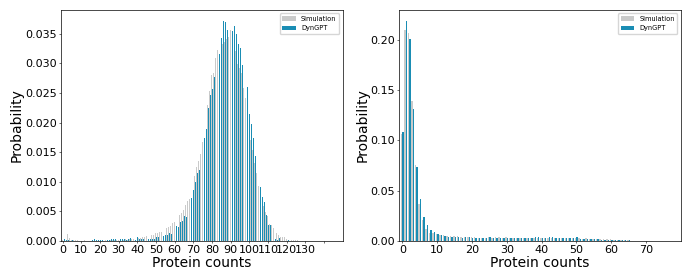

In [6]:
data_index = 0
nn_prob1 = calculate_probabilities(nn_sample_datas[data_index,:,1].astype("int"))
ssa_prob1 = get_ssa_prob(prompt_prob_datasets,data_index)
temp_prob1 = get_Aligned_prob(ssa_prob1,nn_prob1)

data_index=1
nn_prob2 = calculate_probabilities(nn_sample_datas[data_index,:,1].astype("int"))
ssa_prob2 = get_ssa_prob(prompt_prob_datasets,data_index)
temp_prob2 = get_Aligned_prob(ssa_prob2,nn_prob2)

fig,axs = plt.subplots(1,2, figsize=(8, 3))
labels = ["Protein counts","Probability"]
xticks = np.arange(0, 150, 10)
plot_margin_prob(temp_prob1,axs[0],labels,loc_pos=True,xticks=xticks,x_lim=150)

xticks = np.arange(0, 80, 10)
plot_margin_prob(temp_prob2,axs[1],labels,loc_pos=True,xticks=xticks,x_lim=80)